## Imports and Data Set up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns

from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
import shap

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    make_scorer,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
df = pd.read_csv('clean_data_eda.csv')

In [3]:
categorical_cols = ['Month', 'VisitorType', 'Weekend']  # your categorical features

for col in categorical_cols:
    df[col] = df[col].astype('category')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12205 non-null  int64   
 1   Administrative_Duration  12205 non-null  float64 
 2   Informational            12205 non-null  int64   
 3   Informational_Duration   12205 non-null  float64 
 4   ProductRelated           12205 non-null  int64   
 5   ProductRelated_Duration  12205 non-null  float64 
 6   BounceRates              12205 non-null  float64 
 7   ExitRates                12205 non-null  float64 
 8   PageValues               12205 non-null  float64 
 9   SpecialDay               12205 non-null  float64 
 10  Month                    12205 non-null  category
 11  OperatingSystems         12205 non-null  int64   
 12  Browser                  12205 non-null  int64   
 13  Region                   12205 non-null  int64   
 14  Traffi

In [5]:
y = df["Revenue"]
X = df.drop("Revenue", axis=1)

In [6]:
X["Weekend"] = X["Weekend"].astype(int)
X['Month'] = X['Month'].astype("category")
X['Month'] = X['Month'].astype("category")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=67,
    stratify=y
)

## Fit Basic XGBoost Model

In [7]:
clf = xgb.XGBClassifier(
    tree_method="hist",
    enable_categorical=True,
    eval_metric="logloss",
    random_state=67
)
clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Evaluation Function

In [8]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    results = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

    print("Model Evaluation Metrics")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")

    return results

## Evaluate Basic Model

In [9]:
evaluate_model(clf, X_test, y_test)

Model Evaluation Metrics
Accuracy: 0.8980
Precision: 0.7125
Recall: 0.5838
F1-Score: 0.6417
ROC-AUC: 0.9242
PR-AUC: 0.7210


{'Accuracy': 0.8979926259729619,
 'Precision': 0.7124600638977636,
 'Recall': 0.5837696335078534,
 'F1-Score': 0.641726618705036,
 'ROC-AUC': np.float64(0.9241842097902454),
 'PR-AUC': np.float64(0.7209946259146742)}

## Graph Parameters

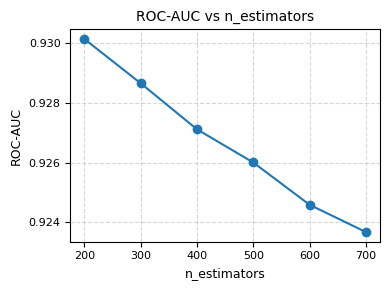

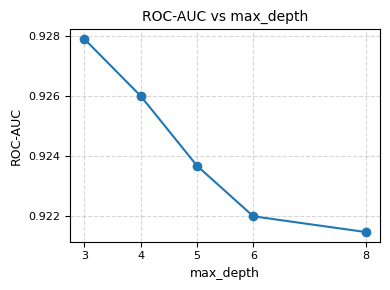

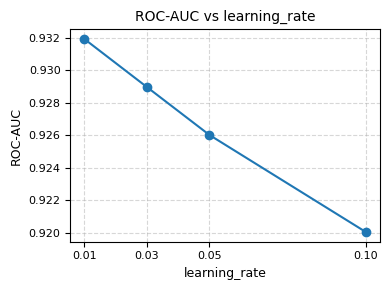

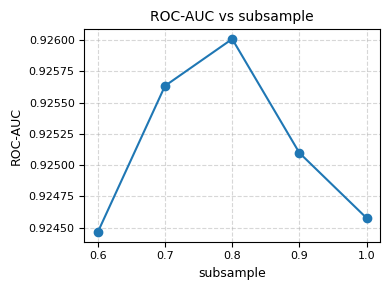

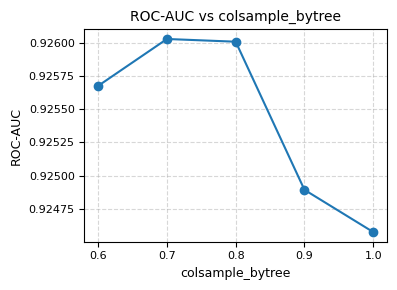

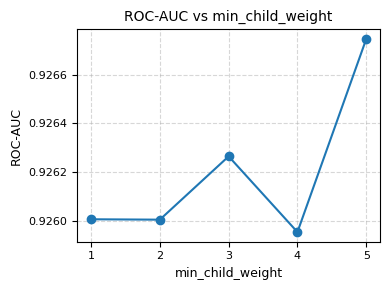

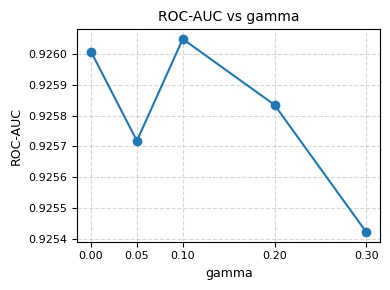

In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

_params = {
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "gamma": 0,
    "scale_pos_weight": scale_pos_weight,
    "tree_method": "hist",
    "enable_categorical": True,
    "eval_metric": "auc",
    "random_state": 67
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

single_param_grid = {
    "n_estimators": [200, 300, 400, 500, 600, 700],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 4, 5],
    "gamma": [0, 0.05, 0.1, 0.2, 0.3]
}

for param, values in single_param_grid.items():
    roc_scores = []
    for v in values:
        params = _params.copy()
        params[param] = v
        model = xgb.XGBClassifier(**params)
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
        roc_scores.append(scores.mean())

    plt.figure(figsize=(4,3))
    plt.plot(values, roc_scores, marker='o')
    plt.xlabel(param, fontsize=9)
    plt.ylabel("ROC-AUC", fontsize=9)
    plt.title(f"ROC-AUC vs {param}", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(values, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

## Tune Parameters to Find Best Model

In [11]:
clf = xgb.XGBClassifier(
    tree_method="hist",
    enable_categorical=True,
    eval_metric="auc",
    random_state=67
)

param_dist = {
    "n_estimators": [50, 100, 200, 300, 400, 500, 600, 700],
    "max_depth": [1, 2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 4, 5, 6, 7],
    "gamma": [0, 0.05, 0.1, 0.2, 0.3],
    "scale_pos_weight": [scale_pos_weight]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

random_search = RandomizedSearchCV(
    clf,
    param_distributions=param_dist,
    n_iter=60,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=67
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=67, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='auc',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow...
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.05, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [1, 2, 3, 4, 5, 6, 8],
                                        'min_child_weight': [1, 2, 3, 4, 5, 6,
                                                             7],
                                        'n_estimators': [50, 100, 200, 300, 400,
                                                         500, 600, 700],
                                        'scale_pos_weight': [np.float64(5.398427260812582)],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=67, scoring='roc_auc', verbose=2)

In [12]:
print("Best Parameters:", random_search.best_params_)

best_model_random_search = random_search.best_estimator_

Best Parameters: {'subsample': 0.8, 'scale_pos_weight': np.float64(5.398427260812582), 'n_estimators': 400, 'min_child_weight': 4, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.05, 'colsample_bytree': 0.8}


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
        "gamma": trial.suggest_float("gamma", 0, 0.2),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 3),
        "scale_pos_weight": scale_pos_weight,
        "tree_method": "hist",
        "eval_metric": "auc",
        "random_state": 67
    }

    model = xgb.XGBClassifier(
    tree_method="hist",
    enable_categorical=True,
    eval_metric="auc",
    random_state=67
)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=80)

best_params = study.best_params
print("Best params:", best_params)

Best params: {'n_estimators': 221, 'max_depth': 6, 'learning_rate': 0.018332203189050336, 'subsample': 0.7673843766473529, 'colsample_bytree': 0.8227980535473102, 'min_child_weight': 2, 'gamma': 0.020624289512428673, 'reg_alpha': 0.5372742683589427, 'reg_lambda': 1.1943767212414185}


In [15]:
best_model_optuna = xgb.XGBClassifier(
    **best_params,
    tree_method="hist",
    enable_categorical=True,
    eval_metric="auc",
    random_state=67
)

best_model_optuna.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8227980535473102, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=0.020624289512428673, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.018332203189050336, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=221, n_jobs=None,
              num_parallel_tree=None, ...)

## Evaluate Best Models

In [16]:
evaluate_model(best_model_random_search, X_test, y_test)

Model Evaluation Metrics
Accuracy: 0.8669
Precision: 0.5486
Recall: 0.8429
F1-Score: 0.6646
ROC-AUC: 0.9388
PR-AUC: 0.7576


{'Accuracy': 0.8668578451454322,
 'Precision': 0.5485519591141397,
 'Recall': 0.8429319371727748,
 'F1-Score': 0.6646026831785345,
 'ROC-AUC': np.float64(0.9387861743488555),
 'PR-AUC': np.float64(0.7575911350572981)}

In [17]:
evaluate_model(best_model_optuna, X_test, y_test)

Model Evaluation Metrics
Accuracy: 0.9050
Precision: 0.7622
Recall: 0.5707
F1-Score: 0.6527
ROC-AUC: 0.9385
PR-AUC: 0.7629


{'Accuracy': 0.9049569848422777,
 'Precision': 0.7622377622377622,
 'Recall': 0.5706806282722513,
 'F1-Score': 0.6526946107784432,
 'ROC-AUC': np.float64(0.9384784969066975),
 'PR-AUC': np.float64(0.7629106625092898)}

The random search method of selecting hyperparameters results in an accuracy of 0.8697 and an ROC-AUC score of 0.9395 whereas the optuna method of selecting hyperparameters results in an accuracy of 0.9009 and an ROC-AUC score of 0.9348. These values are all higher than the accuracy and ROC-AUC score of the basic model, which were 0.9890 and 0.9242 respectively, though not by a huge margin. The optuna search resulted in a higher accuracy while the random search resulted in a higher ROC-AUC score. As such, we will compute feature importance on the model determined by random search.

## Feature Importance Using XGBoost

<Figure size 800x500 with 0 Axes>

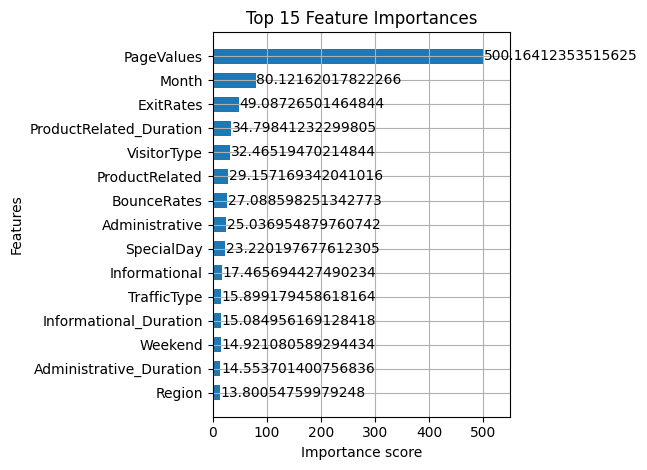

In [18]:
plt.figure(figsize=(8,5))
xgb.plot_importance(best_model_random_search, importance_type='gain', max_num_features=15, height=0.6)
plt.title("Top 15 Feature Importances", fontsize=12)
plt.tight_layout()
plt.show()

## Feature Importance Using SHAP

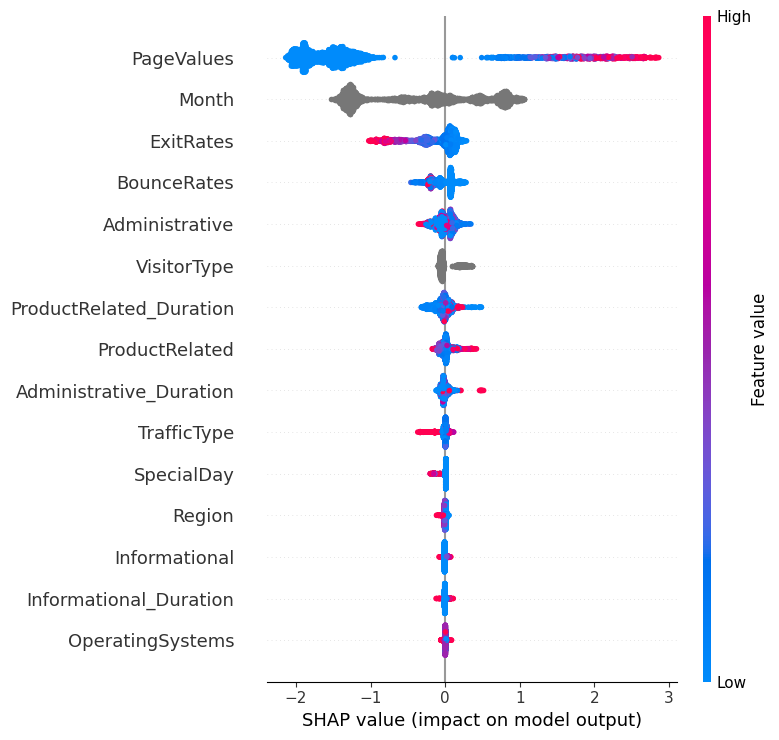

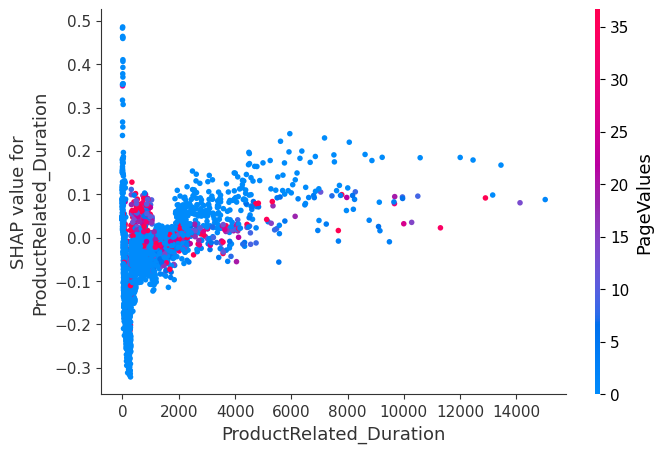

In [19]:
explainer = shap.TreeExplainer(best_model_random_search, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, max_display=15, plot_type="dot")
# Dependence plot
shap.dependence_plot("ProductRelated_Duration", shap_values, X_test)

Most of the top 15 important variables are the same for XGBoost and SHAP, though there is some variability. Based on these calculations, page values is the most imporant variable, followed by month. Visitor type, exit rates, product related duration, and bounce rates are also among the top most important variables. The SHAP plot shows the direct of impact of each of the top 15 variables, with negative values bringing revenue closer to 0 and positive values brining it closer to 1.

Since the most important variable is page value, the SHAP dependence plot shows how page value impacts model predictions. It shows that longer browsing time and high page values increases the likelihood of purchasing.